# MDR-TS v16.4
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v16.4
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

More agressive tunning


For other info see `MDR-TS-v1.0`

## 0. Imports

In [70]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

import torch

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [71]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [72]:
VERSION = "v16"
SUBVERSION = "v16.4"
RUN_NAME = "mdr_ts_v16_4"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v16/v16.4

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [73]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_6.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_6.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_6.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/test.csv


In [74]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 489

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [ ]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
        "SMAP_sm_pm_interp_ema02",
        "V_rollmin_LST_modis_kobs30",
        "D_sin_DOY",
        "G_rain_sum_3d",
        "V_ema_G_API_kobs7",
        "V_rollmin_G_API_kobs30",
        "G_rain_sum_7d",
        "C_lag_LST_modis_kobs30",
        "C_lag_G_API_kobs1",
        "V_ema_G_API_kobs14",
        "V_rollmean_G_API_kobs14",
        "G_API",
        "A_pct_G_API",
        "V_rollcv_G_API_kobs30",
        "G_DSLR",
        "SMAP_ampm_diff_interp",
        "V_rollmax_G_API_kobs30",
        "V_rollmin_G_API_kobs7",
        "V_ema_G_API_kobs30",
        "V_rollmean_s2_b11_kobs7",
        "V_ema_LST_modis_kobs7",
        "C_smm_G_API_alpha0.85_n5",
        "C_lag_G_API_kobs5",
        "V_rollmean_G_API_kobs7",
        "C_lag_s2_b11_kobs30",
        "D_z_LST_modis",
        "A_d_G_API_kobs1",
        "V_rollcv_LST_modis_kobs30",
        "V_rollcv_G_API_kobs7",
        "V_rollstd_LST_modis_kobs30",
        "A_d_E_SAR_diff_kobs14",
        "C_lag_G_API_kobs6",
        "V_rollrng_F_NDMI_kobs7",
        "V_rollcv_G_API_kobs14",
        "C_lag_LST_modis_kobs6",
        "A_d_E_SAR_diff_kobs30",
        "A_d_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollrange7",
        "V_rollstd_LST_modis_kobs14",
        "D_fft_ent_E_SAR_ratio_kobs30",
        "A_d_E_SAR_diff_kobs5",
        "SMAP_sm_pm_interp_rollrange7",
        "V_rollstd_F_NDMI_kobs7",
        "V_rollstd_E_SAR_ratio_kobs7",
        "V_rollrng_E_SAR_diff_kobs7",
        "V_rollstd_s2_b12_kobs7",
        "A_grad_E_SAR_diff_kobs14",
        "D_fft_dom_LST_modis_kobs30",
        "V_rollcv_s2_b12_kobs7",
        "A_d_E_SAR_ratio_kobs5",
        "D_fft_ent_LST_modis_kobs30",
        "V_rollstd_F_NDVI_kobs7",
        "A_grad_s2_b12_kobs7",
        "A_pct_F_NDVI",
        "A_d_s2_b12_kobs2",
        "A_grad_E_SAR_diff_kobs30",
        "A_d_F_NDVI_kobs2",
        "A_grad_E_SAR_diff_kobs7",
        "SMAP_sm_interp_rollrange7",
        "A_d_s2_b12_kobs7",
        "A_d_F_NDVI_kobs1",
        "V_rollcv_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollstd7",
        "V_rollstd_SMAP_sm_interp_kobs7",
        "A_d_s2_b12_kobs5",
        "A_pct_SMAP_sm_interp",
        "SMAP_sm_am_interp_pctchg",
        "V_rollrng_SMAP_sm_interp_kobs7",
        "SMAP_sm_interp_pctchg",
        "A_d_E_SAR_diff_kobs2",
        "G_DSLR_isnan",
        "SMAP_sm_pm_interp_mask",
        "SMAP_sm_interp_mask",
        "SMAP_sm_am_interp_mask",
        "SMAP_sm_am_interp_diff1",
        "SMAP_sm_interp_rollstd7",
        "SMAP_sm_interp_diff1",
        "V_rollstd_E_SAR_diff_kobs7",
        "A_grad_s2_b12_kobs14",
        "A_d_E_SAR_ratio_kobs7",
        "A_grad_LST_modis_kobs14",
        "A_d_SMAP_sm_interp_kobs1",
        "SMAP_sm_pm_interp_pctchg",
        "A_grad_E_SAR_ratio_kobs7",
        "A_d_E_SAR_diff_kobs1",
        "A_d_E_SAR_diff_kobs7",
        "SMAP_sm_pm_interp_diff1",
        "A_d_F_NDVI_kobs5",
        "A_d_E_SAR_ratio_kobs2",
        "A_d_G_API_kobs5",
        "A_d_SMAP_sm_interp_kobs2",
        "D_fft_dom_E_SAR_ratio_kobs30",
        "SMAP_sm_pm_interp_rollstd7",
        "V_rollrng_s2_b12_kobs7",
        "V_rollrng_F_NDVI_kobs7",
        "A_d_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_ratio",
        "V_rollstd_SMAP_sm_interp_kobs30",
        "A_d_E_SAR_ratio_kobs1",
        "A_pct_LST_modis",
        "A_grad_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_diff",
        "SMAP_sm_interp_grad7",
        "A_grad_SMAP_sm_interp_kobs7",
        "A_d_LST_modis_kobs1",
        "V_rollcv_E_SAR_diff_kobs7",
        "A_d_s2_b11_kobs5",
        "V_rollstd_LST_modis_kobs7",

        # spatial
        "slope",
        "elev",
        "K_slope_sin",
        "K_slope_cos",
        "K_aspect_cos",
]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 113
  Target:   soil_moisture_5cm


### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [76]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 -- 2021-09-23

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 -- 2023-11-12

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [77]:
def station_set(df):
    return set(df["station_id"].dropna().unique())

train_st = station_set(train_df)
val_st   = station_set(val_df)
test_st  = station_set(test_df)

print("Stations count:")
print("  train:", len(train_st))
print("  val  :", len(val_st))
print("  test :", len(test_st))

print("\nStations in train but NOT in val:", sorted(train_st - val_st)[:20])
print("Stations in train but NOT in test:", sorted(train_st - test_st)[:20])
print("Stations in val but NOT in train:", sorted(val_st - train_st)[:20])
print("Stations in test but NOT in train:", sorted(test_st - train_st)[:20])

Stations count:
  train: 5
  val  : 4
  test : 5

Stations in train but NOT in val: ['Touchet_WA_824']
Stations in train but NOT in test: []
Stations in val but NOT in train: []
Stations in test but NOT in train: []


In [78]:
def add_drift_features(df, date_col="date", ref_min_year=None, ref_max_year=None,
                       api_col="G_API", smap_col="SMAP_sm_pm_interp_ema02"):

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["year"] = df[date_col].dt.year.astype(float)

    if ref_min_year is None:
        ref_min_year = float(df["year"].min())
    if ref_max_year is None:
        ref_max_year = float(df["year"].max())

    denom = (ref_max_year - ref_min_year) if (ref_max_year > ref_min_year) else 1.0
    df["year_frac"] = (df["year"] - ref_min_year) / denom

    theta = 2 * np.pi * df["year_frac"]
    df["sin_year"] = np.sin(theta)
    df["cos_year"] = np.cos(theta)

    if api_col in df.columns:
        df["API_x_year"] = df[api_col] * df["year_frac"]
    else:
        df["API_x_year"] = np.nan

    if smap_col in df.columns:
        df["SMAP_x_year"] = df[smap_col] * df["year_frac"]
    else:
        df["SMAP_x_year"] = np.nan

    return df, ref_min_year, ref_max_year

train_df_d, y0, y1 = add_drift_features(train_df, ref_min_year=None, ref_max_year=None)
val_df_d, _, _     = add_drift_features(val_df,   ref_min_year=y0, ref_max_year=y1)
test_df_d, _, _    = add_drift_features(test_df,  ref_min_year=y0, ref_max_year=y1)

DRIFT_COLS = ["year_frac", "sin_year", "cos_year", "API_x_year", "SMAP_x_year"]
FEATURE_COLS_D = FEATURE_COLS + DRIFT_COLS

print("Added drift + interaction features:", DRIFT_COLS)
print("New feature count:", len(FEATURE_COLS_D))
print("Train year range:", y0, "to", y1)

missing_api = float(train_df_d["API_x_year"].isna().mean())
missing_smap = float(train_df_d["SMAP_x_year"].isna().mean())
print("Missing rate (train) API_x_year:", missing_api)
print("Missing rate (train) SMAP_x_year:", missing_smap)

Added drift + interaction features: ['year_frac', 'sin_year', 'cos_year', 'API_x_year', 'SMAP_x_year']
New feature count: 118
Train year range: 2011.0 to 2021.0
Missing rate (train) API_x_year: 0.0
Missing rate (train) SMAP_x_year: 0.19508602403959463


In [79]:
trainval_df_d = pd.concat([train_df_d, val_df_d], axis=0).reset_index(drop=True)

trainval_df_d["date"] = pd.to_datetime(trainval_df_d["date"], errors="coerce")
trainval_df_d["year"] = trainval_df_d["date"].dt.year.astype(float)

max_year = trainval_df_d["year"].max()
beta = 0.2

w_trainval = np.exp(beta * (trainval_df_d["year"] - max_year))
w_trainval = w_trainval / w_trainval.mean()

In [80]:
trainval_df_d = pd.concat([train_df_d, val_df_d], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS_D].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df_d[FEATURE_COLS_D].copy()
y_test_d = test_df_d[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (19891, 118)
  X_test_d:     (2829, 118)


### Drift Model (No Weights)

In [81]:
XGB_PARAMS_DRIFT_NO_W = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [82]:
w_trainval_s = pd.Series(w_trainval)
years_tv = trainval_df_d["year"].reset_index(drop=True)

print("Weight stats:")
print(w_trainval_s.describe())

min_year = years_tv.min()
max_year = years_tv.max()

print("Min year weight:", float(w_trainval_s[years_tv == min_year].mean()))
print("Max year weight:", float(w_trainval_s[years_tv == max_year].mean()))

Weight stats:
count    19891.000000
mean         1.000000
std          0.674450
min          0.236939
25%          0.431731
50%          0.786665
75%          1.433397
max          2.611819
Name: year, dtype: float64
Min year weight: 0.2369388678928434
Max year weight: 2.6118189322123544


In [83]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

xgb_drift_no_w_tv = XGBRegressor(**XGB_PARAMS_DRIFT_NO_W)
xgb_drift_no_w_tv.fit(
  trainval_df_d[FEATURE_COLS_D],
  trainval_df_d[TARGET_COL],
  verbose=0,
  )

y_test_d = np.asarray(test_df_d[TARGET_COL]).ravel()
pred_drift_test_no_w = np.asarray(xgb_drift_no_w_tv.predict(test_df_d[FEATURE_COLS_D])).ravel()

print("DRIFT (no W) Test R2:", float(r2_score(y_test_d, pred_drift_test_no_w)))
print("DRIFT (no W) Test bias (true-pred):", float(np.mean(y_test_d - pred_drift_test_no_w)))

DRIFT (no W) Test R2: 0.8115705996742948
DRIFT (no W) Test bias (true-pred): 0.002041062917793417


### Drift Model (With Weights)

In [84]:
XGB_PARAMS_DRIFT_W = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [85]:
trainval_df_d = pd.concat([train_df_d, val_df_d], axis=0).reset_index(drop=True)

xgb_drift_w_tv = XGBRegressor(**XGB_PARAMS_DRIFT_W)
xgb_drift_w_tv.fit(
  trainval_df_d[FEATURE_COLS_D],
  trainval_df_d[TARGET_COL],
  verbose=0,
  sample_weight=w_trainval
  )

y_test_d = np.asarray(test_df_d[TARGET_COL]).ravel()
pred_drift_test_w = np.asarray(xgb_drift_w_tv.predict(test_df_d[FEATURE_COLS_D])).ravel()

print("DRIFT (W) Test R2:", float(r2_score(y_test_d, pred_drift_test_w)))
print("DRIFT (W) Test bias (true-pred):", float(np.mean(y_test_d - pred_drift_test_w)))

DRIFT (W) Test R2: 0.7992983910431484
DRIFT (W) Test bias (true-pred): 0.0019323340793534955


In [86]:
diag_d = test_df_d.copy().reset_index(drop=True)
diag_d["year"] = pd.to_datetime(diag_d["date"], errors="coerce").dt.year
diag_d["y"] = y_test_d
diag_d["pred"] = pred_drift_test_w

d2023 = diag_d[diag_d["year"] == 2023].copy()

if len(d2023) >= 2:
    r2_2023 = float(r2_score(d2023["y"], d2023["pred"]))
    a, b = np.polyfit(d2023["pred"], d2023["y"], 1)  # y ≈ a*pred + b
    print("\nDRIFT 2023 R2:", r2_2023)
    print("DRIFT 2023 slope:", float(a), "intercept:", float(b))
else:
    print("\nNo 2023 rows found in DRIFT test slice.")


DRIFT 2023 R2: 0.002914473728169442
DRIFT 2023 slope: 0.8619968621991304 intercept: 0.0539488050884315


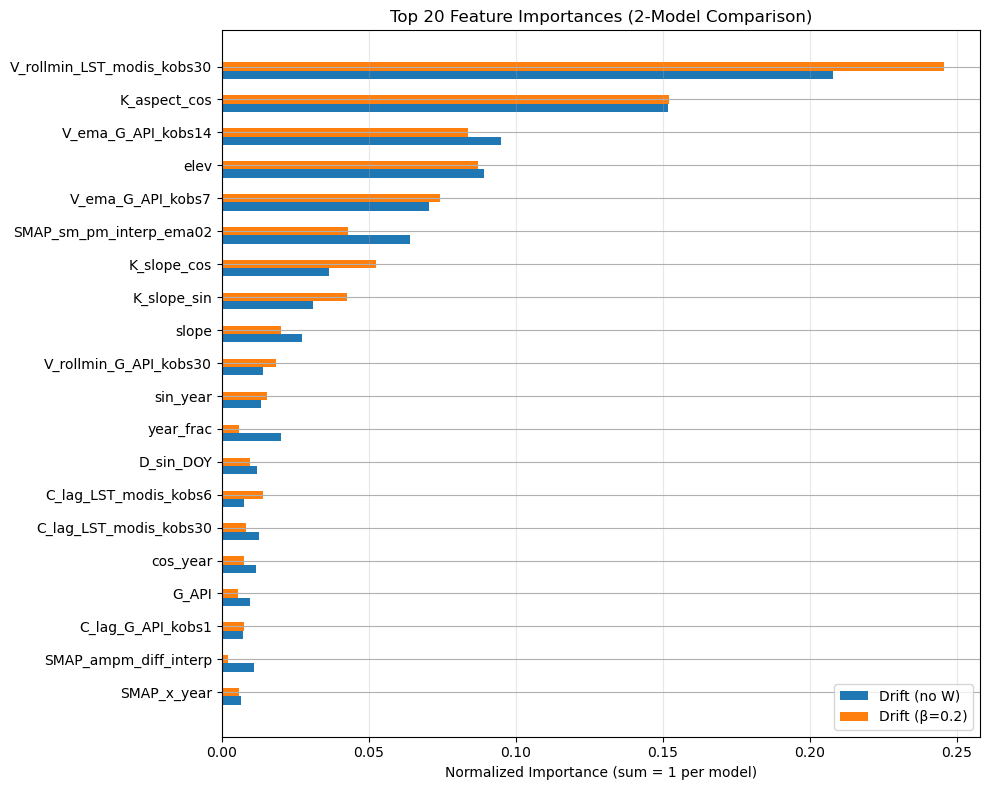

In [87]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()
    return imp

def get_rf_importance(model, feature_cols):
    rf_model = model.named_steps["model"] if hasattr(model, "named_steps") else model
    imp = pd.Series(rf_model.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()
    return imp

imp_no_w = get_xgb_importance(xgb_drift_no_w_tv, FEATURE_COLS_D)
imp_w    = get_xgb_importance(xgb_drift_w_tv, FEATURE_COLS_D)

all_feats = sorted(set(imp_no_w.index) | set(imp_w.index))

cmp = pd.DataFrame({
    "drift_no_w": imp_no_w.reindex(all_feats, fill_value=0.0),
    "drift_w":    imp_w.reindex(all_feats, fill_value=0.0),
})

cmp["consensus_mean"] = cmp.mean(axis=1)

TOP_K = 20
cmp_top = cmp.sort_values("consensus_mean", ascending=False).head(TOP_K)

cmp_top_sorted = cmp_top.sort_values("consensus_mean", ascending=True)
plot_df = cmp_top_sorted[["drift_no_w", "drift_w"]]

plt.figure(figsize=(10, 8))
y = np.arange(len(plot_df))

plt.barh(y - 0.25, plot_df["drift_no_w"].values, height=0.25, label="Drift (no W)")
plt.barh(y,         plot_df["drift_w"].values,    height=0.25, label="Drift (β=0.2)")

plt.yticks(y, plot_df.index)
plt.xlabel("Normalized Importance (sum = 1 per model)")
plt.title(f"Top {TOP_K} Feature Importances (2-Model Comparison)")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
display(cmp_top)

,drift_no_w,drift_w,consensus_mean
V_rollmin_LST_modis_kobs30,0.207815,0.245644,0.226730
K_aspect_cos,0.151789,0.152245,0.152017
V_ema_G_API_kobs14,0.095052,0.083867,0.089460
elev,0.089040,0.086996,0.088018
V_ema_G_API_kobs7,0.070278,0.074283,0.072280
SMAP_sm_pm_interp_ema02,0.064088,0.042937,0.053512
K_slope_cos,0.036425,0.052526,0.044475
K_slope_sin,0.031028,0.042607,0.036817
slope,0.027113,0.019977,0.023545
V_rollmin_G_API_kobs30,0.014112,0.018527,0.016319


---

_Jakob Balkovec_